# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

### Загрузка библиотек и установление констант

In [ ]:
# подгружаем и обновляем необходимые библиотеки
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q

!pip install scikit-learn==1.5.2 -q # обновление для корректной работы некоторых частей кода

# модели
!pip install lightgbm -q # LightGBM

# работа с текстом
!pip install contractions # # для обработки апострофов в сокращениях (I'm -> I am)

In [ ]:
# подключаем библиотеки
import pandas as pd # работа с данными в формате таблиц
import numpy as np  # математические операции и работа с массивами
import time # расчет времени выполнения функций

# визуализация данных
import matplotlib.pyplot as plt # для некоторых графиков
import seaborn as sns # для некоторых графиков и матриц

# визуализация прогресса
from tqdm.auto import tqdm  # автоматический выбор режима
#from tqdm.notebook import tqdm # версия для ноутбука юпитер, может не работать в другой среде
tqdm.pandas()  # активируем progress_apply для pandas

# работа с текстом
from contractions import fix # для обработки апострофов в сокращениях (I'm -> I am)
import re # модуль регулярных выражений
# подключение "фильтра" стоп-слов
import nltk # библиотека инструментария естественного языка
from nltk.corpus import stopwords # модуль со стоп-словами
nltk.download('stopwords') # загружаем сам модуль
nltk.download('wordnet') # лексическая база данных для английского языка
nltk.download('punkt') # токенизатор для разбиения текста на предложения и слова
# библиотека предоставляет специализированные типы данных-контейнеры, которые расширяют возможности стандартных структур
from collections import Counter # подскласс словаря, предназначенный для подсчета частоты элементов в итеррируемом объекте
from nltk.tokenize import word_tokenize # функция для токенизации текста, то есть разбиения его на отдельные слова или токены
# лемматизация:
from nltk.stem import WordNetLemmatizer #  класс для лемматизации слов, то есть приведения их к начальной форме
from nltk import pos_tag # модуль для определения и присвоения частей речи (POS — Part-Of-Speech) словам в тексте
# Загрузка необходимых данных NLTK (выполнить один раз), требуется для работы POS
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# указываем язык, уедет дальше
#stopwords = list(nltk_stopwords.words('english'))  # преобразуем в list, а не set
# дополнительная подготовка текстовых данных для МО
from sklearn.feature_extraction.text import TfidfVectorizer # класс для рассчета частот употребления (TF-IDF)
from sklearn.feature_extraction.text import CountVectorizer # счетчик для мешка слов

# разбиение на выборки
from sklearn.model_selection import train_test_split # для разбивки на выборки для МО
from sklearn.utils import shuffle # перемешивание данных для уравновешивания их в разных выборках

# модель и ее метрика
from sklearn.dummy import DummyClassifier # базовая даммми-модель для сравнения
from sklearn.linear_model import LogisticRegression # логистическая регрессия
from lightgbm import LGBMClassifier # LightGBM модель
from sklearn.metrics import (
                        # метрика для проекта
                        f1_score, # F1-метрика
                        # допработа
                        # визуализация ошибок (и метрики, которые нам понадобятся)
                        confusion_matrix, # матрица ошибок
                        precision_recall_curve,
                        roc_curve,
                        auc,
                        PrecisionRecallDisplay,
                        RocCurveDisplay,
                        ConfusionMatrixDisplay # класс для визуализации матрицы ошибок в виде тепловой карты или таблицы
                        )

# перебор парметров модели
from sklearn.model_selection import (
    GridSearchCV, # автоподбор параметров моделей
    #кросс-валидация:
    KFold, # создание блоков
    cross_val_score # оценка модели на кросс-валидации
    )
# работа с пайплайнами
#класс, который позволяет объединить несколько шагов обработки данных в одну структуру.
# он принимает список кортежей, где каждый кортеж содержит название шага и соответствующий объект-преобразователь или модель
from sklearn.pipeline import Pipeline # пайплайны

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# задаем настройки отображения

# настройки дисплея
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format

# настройки графиков библиотеки sns
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

## warnings.simplefilter(action='ignore', category=FutureWarning)
#pd.options.mode.chained_assignment = None

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# задаем константы
# для фиксации объектов тренировочной и тестовой выборок, а также в некоторых рандомах
RANDOM_STATE = 42
# для пропорционального разделения датасета на тренировочную и тестовую выборки
TEST_SIZE = 0.1

**Вывод**

Необходимые для работы библиотеки подключены, константы заданы, стиль отображения настроен.

### Загрузка данных и краткий обзор

Загрузим наш датасет и посмотрим краткую информацию о нем.

In [ ]:
#ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка датасета
try:
    comments = pd.read_csv('/datasets/toxic_comments.csv')
except:
    comments = pd.read_csv('https://адрес_удален/datasets/toxic_comments.csv')

In [ ]:
# функция для краткого обзора и описания
def first_discr(data, titl, num):

  print(color.BLUE + color.BOLD + f"\n === Первые {num} строк в {titl}: ===\n" + color.END)
  display(data.head(num))

  print(color.BLUE + color.BOLD + f"\n === Общая информация о данных в {titl}: ===\n" + color.END)
  display(data.info())

  print(color.BLUE + color.BOLD + f"\n === Размер датасета {titl}:===\n" + color.END + f"    {data.shape}\n")

  return

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(comments,'полученном датасете', 5)


 === Первые 5 строк в полученном датасете: ===



,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0



 === Общая информация о данных в полученном датасете: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


None


 === Размер датасета полученном датасете:===
    (159292, 3)



Тип данных в столбцах соответствует содержимому. И мы можем увидеть, что используемый язык - английский, а также в некоторых комментариях сохранились отметки с IP комментатора или дате и времени оставления комментария либо служебные символы (например, \n), что что будет необходимо учесть в будущем.

Явные пропуски в наших данных отсутствуют.

Также мы имеем безымянный столбец, вероятно дублирующий индекс. Избавиться от него мы можем несколькими путями:
- перезагрузить датасет заново, используя pd.read_csv('...', index_col=0).
- удалить столбец в уже загруженном затасете.

Чтобы не обращаться заново к месту хранения информации за новой загрузкой, быстрее будет удалить столбец у уже имеющегося датасета. Но сначала подтвердим наше предположение.

In [ ]:
# проверяем распределение данных признака Unnamed: 0 на монотонность,
# выводим стат данные
display(comments['Unnamed: 0'].is_monotonic)
display(comments['Unnamed: 0'].describe())

True

count   159,292.00
mean     79,725.70
std      46,028.84
min           0.00
25%      39,872.75
50%      79,721.50
75%     119,573.25
max     159,450.00
Name: Unnamed: 0, dtype: float64

Данные столбец представляет собой последовательность чисел от 0 до 159 450, то есть, вероятно, это были старые индексы, до того как из датасета удалили наиболее проблемные по каким-либо причинам строки.

In [ ]:
# удаляем столбец
comments = comments.drop('Unnamed: 0', axis = 1)
comments.head() # проверяем

,text,toxic
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0
4,"You, sir, are my hero. Any chance you remember what page that's on?",0


Лишний столбец удален.

**Вывод**

Датасет с данными загружен. В процессе краткого обзора обнаружено:
- Язык текстов - английский.
- Наши данные - не очищенные: в некоторых комментариях сохранились отметки с IP комментатора или дате и времени оставления комментария либо служебные символы (например, \n), что будет необходимо учесть при обработке данных.
- Наличие дополнительного столбца, дублирующего прежний индекс, который был нами в последствие удален.
- Типы данных столбцов соответстуют содержимому.
- Явные пропуски отсутствуют.

### Анализ и предварительная очистка данных

Как мы могли увидеть, наши данные имеют "артефакты", от которых будет необходимо в будущем избавиться.

Но пока осмотрим данные на предмет других проблем.

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество явных дубликатов: "+ color.END + f"{comments.duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент явных дубликатов: "+ color.END +
      f"{comments.duplicated().sum()/len(comments)*100:.2f} %")

Количество явных дубликатов: 0
Процент явных дубликатов: 0.00 %


Явные дубликаты отсутствуют. А если неявные, которые при одинаковом содержимом сумели получить разные отметки о токсичности?

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество неявных дубликатов: "+ color.END + f"{comments['text'].duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент неявных дубликатов: "+ color.END +
      f"{comments['text'].duplicated().sum()/len(comments)*100:.2f} %")

Количество неявных дубликатов: 0
Процент неявных дубликатов: 0.00 %


Такие ошибки в данных также отсутствуют.

Посмотрим, нет ли у нас "лишних" меток при маркировке.

In [ ]:
# смотрим уникальные значения
comments['toxic'].unique()

array([0, 1])

Мы не можем знать, насколько верно "по смыслу" были размечены комментарии в датасете, однако мы можем сказать, что сами метки "по форме" использовались правильные.

Теперь начнем обрабатывать данные. Для начала, переведем их все в нижний регистр. Это позволит вычленить скрытые дубли уже сейчас и упростить проуесс подготовки данных в будущем.

Но для начала создадим копию, чтобы при необходимости можно было обратиться к исходному датасету.

In [ ]:
# создаем копию
comm = comments.copy()
comm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


Копия создана, можно преходить к обработке.

In [ ]:
# приводим в нижний регистр
comm.text = comm.text.str.lower()

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество явных дубликатов: "+ color.END + f"{comm.duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент явных дубликатов: "+ color.END +
      f"{comm.duplicated().sum()/len(comm)*100:.2f} %")

Количество явных дубликатов: 45
Процент явных дубликатов: 0.03 %


Теперь явные дубликаты появились. А может быть появились еще и дубли с разной разметкой?

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество неявных дубликатов: "+ color.END + f"{comm['text'].duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент неявных дубликатов: "+ color.END +
      f"{comm['text'].duplicated().sum()/len(comm)*100:.2f} %")

Количество неявных дубликатов: 46
Процент неявных дубликатов: 0.03 %


Да, один из комментариев получил разные метки. Посмотрим на него из интереса.

In [ ]:
# смотрим эту строку
comm[comm['text'].duplicated()][~comm[comm['text']\
                                    .duplicated()].index.isin(comm[comm.duplicated()].index)]

,text,toxic
135396,removing irrelevant nonsense\n\nad hominem attack in place of reasonable argument shows the bankruptcy of\nthose who which to silence me.\n\nmore you do more persistent i will be come.,0


In [ ]:
# смотрим версию комментария
comments.loc[135396]

text     REMOVING IRRELEVANT NONSENSE\n\nAd hominem ATTACK IN PLACE OF REASONABLE ARGUMENT SHOWS THE BANKRUPTCY OF\nTHOSE WHO WHICH TO SILENCE ME.\n\nMORE YOU DO MORE PERSISTENT i WILL BE COME.
toxic                                                                                                                                                                                           0
Name: 135396, dtype: object

По смыслу этот комментарий мог бы считаться токсичным (к тому же здесь использованы исключительно прописные буквы), однако какой-то из разметчиков не счел его таковым, в результате чего он попал в базу в двух вариантах.

Удалим все наши дубли, индексы же будем сохранять для того, чтобы иметь возможность обратиться по ним к исходному датасету.

In [ ]:
# удаляем
comm = comm.drop_duplicates(subset=['text'], ignore_index=False)

In [ ]:
# проверяем
print(color.BLUE + color.BOLD +f"Количество неявных дубликатов: "+ color.END + f"{comm['text'].duplicated().sum()}")

Количество неявных дубликатов: 0


Дубли удалены, а значит данные стали немного чище.

Теперь взглянем на соотношение классов в нашем датасете.

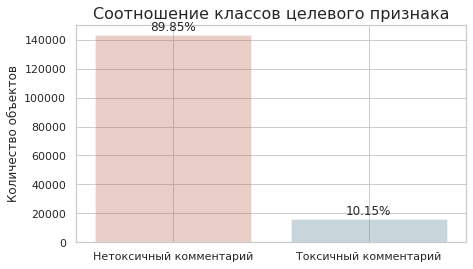

In [ ]:
# соотношение классов в датасете
# вариант с баром с подписанными процентами

# создаем сводную таблицу для будущего построения
temp = comm.pivot_table(index='toxic', # строки таблицы будут сгруппированы по значениям данного столбца
                            values='text', # значения будут основаны на этом столбце.
                            aggfunc='count', # функция агрегации - количество значений
                            margins=True) # добавление строки с итогами
temp.columns = ['count'] # изменяем название столбца на 'count'
# добавляем столбец 'percentage', который вычисляет процентное соотношение каждого класса к общему количеству объектов
temp['percentage'] = temp.apply(
    lambda x: (x.values / temp.loc['All', 'count'] * 100).round(2)
)
# удаляем строку с итогами, соответствующую 'All'
temp = temp.drop('All', axis=0)

plt.figure(figsize=(7, 4))
pal = sns.diverging_palette(220, 20, n=2)

ax = sns.barplot(data=temp, x=temp.index, y='count', palette=pal,
                 hue='count', dodge=False, alpha=.3)

# Добавляем подписи для каждого столбца
for i, (index, row) in enumerate(temp.iterrows()):
    ax.text(i, row['count'] + 1000,  # +1000 для небольшого отступа от вершины столбца
            f"{row['percentage']}%",
            ha='center',
            va='bottom',
            fontsize=12)

plt.xticks([0, 1], ['Нетоксичный комментарий', 'Токсичный комментарий'])
ax.set_xlabel('')
ax.set_ylabel('Количество объектов')
ax.set_title('Соотношение классов целевого признака')
ax.get_legend().remove()
ax.grid(True)

Как мы видим, датасет у нас несбалансированный, что требуется учесть при разбиении на выборки.

Также мы можем предположить, что комьюнити данного магазина вполне доброжелательное в целом.

**Выводы**

- В датасете оказались замаскированные разностью регистров дубликаты, один из которых получил разные метки. Дубликаты были удалены.
- При разметке данных использовались только 1 и 0.
- Комьюнити данного магазина в целом дружелюбное, что привело к дисбалансу классов в нашем датасете: токсичные комментарии в нем составляют чуть более 10%.

### Дополнительная очистка, токенизация и лемметизация текста

Мы уже привели текст к нижнему регистру, но теперь необходимо избавиться от спецсимволов и привести слова к леммам. Возможно, в результате мы также получим строки, которые не имеют смысла (например, состоящие только из спецсимволов) и от которых придется избавиться.

Частицу 'not' мы сохраним, так как ее наличие или отсутсвие может менять смысл на противоположный.

In [ ]:
# функция для конвертации Penn Treebank tags в WordNet tags
# нужна для последующей лемматизации текста
def penn2morphy(penntag):
    """Converts Penn Treebank tags to WordNet."""
    morphy_tag = {'NN':'n', 'JJ':'a',
                  'VB':'v', 'RB':'r'}
    try:
        return morphy_tag[penntag[:2]]
    except:
        return 'n' # по умолчанию считаем существительным

In [ ]:
# подготовка к созданию функции
# стоп-слова
# stop_words = stopwords.words('english')
stop_words = set(stopwords.words('english')) # выбираем нужный язык, создаем множество (set) для более быстрого поиска стоп-слов
stop_words.remove('not') # исключаем из этого списка слово not для сохранения смысла в негативных контекстах
lemmatizer = WordNetLemmatizer() # создаем объект для лемматизации

# сама функция обработки текстов
def data_clean(text):
    # видимо, тут можно не использовать, так как результат не меняется
    text = fix(text) # для обработки апострофов в сокращениях (I'm -> I am)

    # удаляем всё между (talk) и (utc) включительно
    '''
    `\(talk\).*?\(utc\)` работает так:
   - `\(talk\)` — ищет точное вхождение "(talk)"
   - `.*?` — "нежадный" поиск любого символа (чтобы захватить минимальный текст между маркерами)
   - `\(utc\)` — ищет точное вхождение "(utc)"
   - `flags=re.IGNORECASE` — игнорирует регистр (найдет и `(Talk)`, и `(UTC)`)
    '''
    text = re.sub(r'\(talk\).*?\(utc\)', ' ', text, flags=re.IGNORECASE)

    # удаляем оставшиеся изолированные (talk) или (utc)
    text = re.sub(r'\((talk|utc)\)', ' ', text, flags=re.IGNORECASE)

    # остальная очистка
    #text_clean = re.sub(r"[^A-Za-z'\s]", ' ', text)  # оставляем только слова и апострофы, без чисел
    text_clean = re.sub(r"[^a-z'\s]", ' ', text)  # уже упрощено, так как у нас уже все в нижнем регистре
    text_clean = re.sub(r'\s+', ' ', text_clean).strip() # удаляем двойные пробелы и обрезаем края

    # токенизация
    tokens = word_tokenize(text_clean)

    # POS-тегирование и лемматизация с учетом части речи
    pos_tags = pos_tag(tokens)
    # если не известно, в каком регистре, то приводим к строчному через .lower()
    lemm = [
        #lemmatizer.lemmatize(word.lower(), pos=penn2morphy(tag))
        # у нас уже приведено к строчному заранее
        lemmatizer.lemmatize(word, pos=penn2morphy(tag))
            for word, tag in pos_tags
            if word.lower() not in stop_words
    ]

    return ' '.join(lemm)

Чтобы не тратить ресурсы сразу, проверим корректность преобразования на одной строке датасета.

In [ ]:
# проверка на первой строке
data_clean(comm['text'][0])

'explanation edits make username hardcore metallica fan revert not vandalisms closure gas vote new york doll fac please not remove template talk page since retire'

In [ ]:
# выводим исходный текст для сравнения
comm['text'][0]

"explanation\nwhy the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now.89.205.38.27"

Очистка и лемматизация прошла успешно, можно повторить на всем датасете.

In [ ]:
# производим очистку (со шкалой прогресса)
comm['lemm'] = comm['text'].progress_apply(lambda text: data_clean(text))

  0%|          | 0/159246 [00:00<?, ?it/s]

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 </div>

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(comm,'подготовленном датасете', 10)


 === Первые 10 строк в подготовленном датасете: ===



,text,toxic,lemm
0,"explanation\nwhy the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now.89.205.38.27",0,explanation edits make username hardcore metallica fan revert not vandalisms closure gas vote new york doll fac please not remove template talk page since retire
1,"d'aww! he matches this background colour i'm seemingly stuck with. thanks. (talk) 21:51, january 11, 2016 (utc)",0,d'aww match background colour seemingly stick thanks
2,"hey man, i'm really not trying to edit war. it's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. he seems to care more about the formatting than the actual info.",0,hey man really not try edit war guy constantly remove relevant information talk edits instead talk page seem care formatting actual info
3,"""\nmore\ni can't make any real suggestions on improvement - i wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -i think the references may need tidying so that they are all in the exact same format ie date format etc. i can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nthere appears to be a backlog on articles for review so i guess there may be a delay until a reviewer turns up. it's listed in the relevant form eg wikipedia:good_article_nominations#transport """,0,not make real suggestion improvement wonder section statistic later subsection type accident think reference may need tidy exact format ie date format etc later one else first preference format style reference want please let know appear backlog article review guess may delay reviewer turn list relevant form eg wikipedia good article nomination transport
4,"you, sir, are my hero. any chance you remember what page that's on?",0,sir hero chance remember page
5,"""\n\ncongratulations from me as well, use the tools well. · talk """,0,congratulation well use tool well talk
6,cocksucker before you piss around on my work,1,cocksucker piss around work
7,"your vandalism to the matt shirvington article has been reverted. please don't do it again, or you will be banned.",0,vandalism matt shirvington article revert please not ban
8,"sorry if the word 'nonsense' was offensive to you. anyway, i'm not intending to write anything in the article(wow they would jump on me for vandalism), i'm merely requesting that it be more encyclopedic so one can use it for school as a reference. i have been to the selective breeding page but it's almost a stub. it points to 'animal breeding' which is a short messy article that gives you no info. there must be someone around with expertise in eugenics? 93.161.107.169",0,sorry word 'nonsense ' offensive anyway not intend write anything article wow would jump vandalism merely request encyclopedic one use school reference selective breeding page almost stub point 'animal breed ' short messy article give info must someone around expertise eugenics
9,alignment on this subject and which are contrary to those of dulithgow,0,alignment subject contrary dulithgow



 === Общая информация о данных в подготовленном датасете: ===

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159246 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159246 non-null  object
 1   toxic   159246 non-null  int64 
 2   lemm    159246 non-null  object
dtypes: int64(1), object(2)
memory usage: 8.9+ MB


None


 === Размер датасета подготовленном датасете:===
    (159246, 3)



Нам удалось лемметизировать текст, предварительно избавившись от различных "артефактов".

**Вывод**

Текст подготовлен для дальнейшей работы с моделью.

### Анализ очищенного текста и его доработка

Прежде чем переходить к работе с моделью, немного изучим очищенный результат. Возможно, стоит его еще доработать?

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество неявных дубликатов: "+ color.END + f"{comm['lemm'].duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент неявных дубликатов: "+ color.END +
      f"{comm['lemm'].duplicated().sum()/len(comm)*100:.2f} %")

Количество неявных дубликатов: 1822
Процент неявных дубликатов: 1.14 %


После очистки у нас внось появились дубли. Так как это хоть и были изначально разные комментарии, но модель работает с леммами, в которых они стали одинаковыми. Поэтому дубли могут привести к утечке данных.

Посмотрим, получали ли такие дубли разную метку?

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество явных дубликатов в подготовленном тексте: "\
      + color.END + f"{comm.drop('text', axis = 1).duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент явных дубликатов: "+ color.END +
      f"{comm.drop('text', axis = 1).duplicated().sum()/len(comm)*100:.2f} %")

Количество явных дубликатов в подготовленном тексте: 1784
Процент явных дубликатов: 1.12 %


In [ ]:
print(color.BLUE + color.BOLD +f"Количество строк, получивших разные метки: "\
      + color.END + f"{comm['lemm'].duplicated().sum() - comm.drop('text', axis = 1).duplicated().sum()}")

Количество строк, получивших разные метки: 38


In [ ]:
# Находим строки, которые дублируются по 'lemm', но не дублируются по остальным столбцам (кроме 'text')
comm[comm['lemm'].duplicated(keep=False) & ~comm.drop('text', axis=1).duplicated(keep=False)]

,text,toxic,lemm
3965,"""\n\nyour serious mental illness and addiction\n\nthis is the most """"contructive"""" thing that can ever be contributed as it relates to you and your involvement here: please stop and think about the depth of your sickness, sitting there, with your face glued to your computer screen, uncompensated day after day, week after week, for years, tinkering with the biographies of people you don't even know, who actually are out living real lives while you are imprisoned by your addiction. you have literally wasted years of your life with this lonely, self-destructive addiction and illness, which has been at the expense of living your own life. the depth of your mental illness must make it difficult for you to see the extraordinary insanity of your actions and how your addiction has stripped you of the life that was given you. \n\ni know a few others have evaluated what you do here and laugh at you and your sickness. it's something of an inside joke, and i guess few share it with you because they consider you hopeless. that's not right either, and i'd ask them to please stop that and try to help you. don't laugh at this person behind their back and then just communicate with them on routine matters. that lacks all caring for a person who has an obvious and very serious illness. something is very wrong with him/her, and while it may not be for us to diagnose the exact problem, we should pause to help with advice. please share with him/her what we all know. it's only humane to do so. \n\ni will do so now too:\n\njerzy (or whatever your name isconsciously concealed, i'm sure, to keep your illness as private as possible), please consider some uncomfortable facts: years of your life have now been totally consumed and absolutely wasted by your deep, deep sickness and obvious addiction. please don't make excuses for yourself. you cannot go on like this any longer. you need to stop, and you need to stop today. reject this advice, and i worry that your sickness will probably only deepen and your addiction will waste whatever is left of your life. please stop. it's over. enough. move on. i do wish you the best and hope you will take this friendly advice seriously. it will be the first and last time i share it, and i hope you know that i share it only with your best interests in mind. it's sad what has happened to you, but i wish you good luck and hope this advice is helpful. but please take itand do so today. you cannot go on like this.""",0,serious mental illness addiction contructive thing ever contribute relate involvement please stop think depth sickness sit face glue computer screen uncompensated day day week week year tinker biography people not even know actually live real life imprison addiction literally waste year life lonely self destructive addiction illness expense live life depth mental illness must make difficult see extraordinary insanity action addiction strip life give know others evaluate laugh sickness something inside joke guess share consider hopeless not right either would ask please stop try help not laugh person behind back communicate routine matter lack caring person obvious serious illness something wrong may not u diagnose exact problem pause help advice please share know humane jerzy whatever name isconsciously conceal sure keep illness private possible please consider uncomfortable fact year life totally consume absolutely waste deep deep sickness obvious addiction please not make excuse not go like long need stop need stop today reject advice worry sickness probably deepen addiction waste whatever leave life please stop enough move wish best hope take friendly advice seriously first last time share hope know share best interest mind sad happen wish good luck hope advice helpful please take itand today not go like
4301,i am not a vandal!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!,1,not vandal
8286,"i sincerely wish i could meet you chumps \n \nyou freaks really get my goat. etaonsh(still stuck in 1940'

Среди данных комментариев есть как развернутые (некоторые из которых выглядят как повторение одного и того же), так и краткие. Можно в качестве примера отдельно вывести один из них.

In [ ]:
comm[comm['lemm'] == 'not vandal']

,text,toxic,lemm
4301,i am not a vandal!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!,1,not vandal
89118,i am not a vandal! 82.33.160.8,0,not vandal


В целом текст там один и тот же, но вот количество восклицательных знаков - разное. Возможно, там изначально было использование прописных букв (так называемого Капса), за что и была получена метка токсичности?

In [ ]:
# смотрим токсичную версию комментария
comments.loc[4301]

text     I AM NOT A VANDAL!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
toxic                                                  1
Name: 4301, dtype: object

In [ ]:
# смотрим нетоксичную версию комментария
comments.loc[89118]

text     I am not a vandal! 82.33.160.8
toxic                                 0
Name: 89118, dtype: object

Действительно, разница в этих двух комментариях (не считая отметки IP у второго) - в использовании прописных букв и большого количества восклицательных знаков для токсичного комментария и строчных и малого количество - для нетоксичного.

Возможно, потенциально необходимо будет создать новые признаки, которые будут это учитывать. С другой стороны, мы уже видели ранее, что и тексты с исключительно прописными буквами также иногда были засчитаны как нетоксичные. Поэтому было бы неплохо уточнить критерии изначальной разметки и перепроверить качество исполнения при возможности.

Но пока разные метки будут лишь сбивать с толку нашу модель. Поэтому удалим все дубликаты в столбце `'lemm'`.

In [ ]:
# удаляем
comm = comm.drop_duplicates(subset=['lemm'], ignore_index=False)

In [ ]:
# проверяем
print(color.BLUE + color.BOLD +f"Количество неявных дубликатов: "+ color.END + f"{comm['lemm'].duplicated().sum()}")

Количество неявных дубликатов: 0


Теперь посмотрим на количество слов, характерных для комментариев.

In [ ]:
# подсчитываем кол-во слов в текстах
comm['lemm'].apply(lambda x: len(x.split())).describe()

count   157,424.00
mean         36.07
std          55.61
min           0.00
25%           9.00
50%          19.00
75%          39.00
max       1,250.00
Name: lemm, dtype: float64

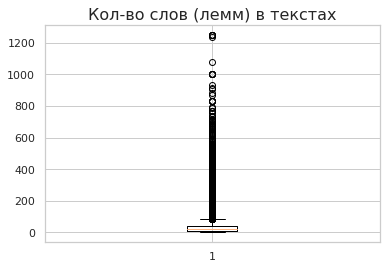

In [ ]:
# строим диаграмму размаха,
# визуализируем распределение данных
plt.boxplot(comm['lemm'].apply(lambda x: len(x.split())).values)
plt.grid(True)
plt.title('Кол-во слов (лемм) в текстах');

Основное количество комментариев содержит не более ста слов. Среднее же их количество 36, а большая часть не превышает 39.

Также есть выбросы (максимальный размер текста - 1250) и есть очень много содержащих большое количество, и часть из которых которые можно назвать полноценными текстами. Наверняка, с учетом их размера, там могут быть высказаны разные мысли как токсического, так и не токсического характера. Поэтому, вероятно, было бы удобнее в будущем разбивать их на фрагменты для более точного анализа.

Посчитаем, сколько у нас текстов с более чем 200 словами.

In [ ]:
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество 'длинных строк': "+ color.END +
      f"{comm['lemm'].apply(lambda x: len(x.split()) > 200).sum()}")
print(color.BLUE + color.BOLD +f"Процент 'длинных строк': "+ color.END +
      f"{comm['lemm'].apply(lambda x: len(x.split()) > 200).sum()/len(comm)*100:.2f} %")

Количество 'длинных строк': 3435
Процент 'длинных строк': 2.18 %


In [ ]:
# считаем
comm['lemm'].apply(lambda x: len(x.split()) > 200).sum()

3435

Таких комментариев немного. Как уже было сказано выше, что в таких комментариях может быть изложено несколько мыслей разной токсичности. Но предположим, что при разметке считалось, что если хоть одна из этих мыслей - токсичная, то и весь комментарий - тоже, и должен отправиться на модерацию. Поэтому пока сохраним их в датасете.

Посмотрим на наиболее часто встречающиеся слова в токсичных и нетоксичных комментариях.

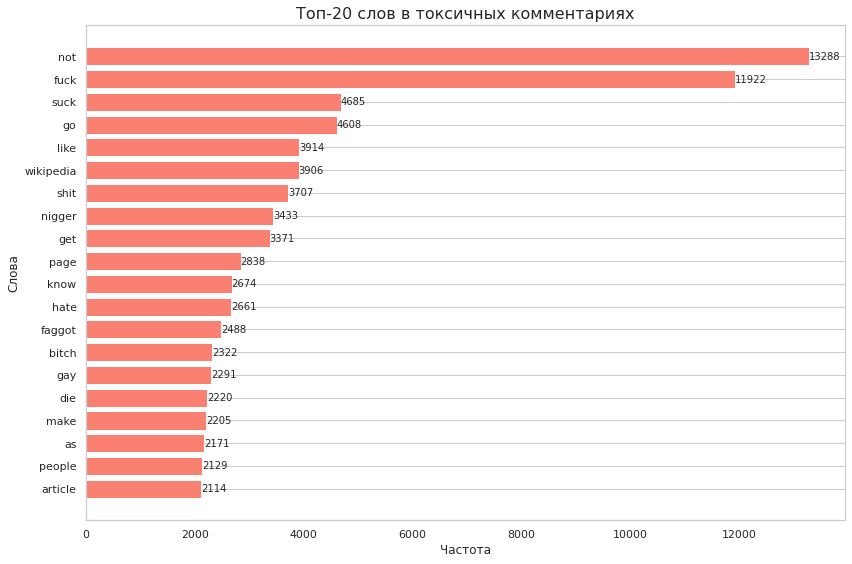

In [ ]:
# визуализация частоты слов в токсичных комментариях
# с подписями самих шкал
# данные (уже без стоп-слов)
toxic_text = " ".join(comm[comm['toxic'] == 1]['lemm'].dropna().tolist())

# считаем частоту и берем топ-20
word_freq = Counter(toxic_text.split())
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)  # Разделяем слова и частоты

# создаем график
plt.figure(figsize=(12, 8))
bars = plt.barh(words, counts, color='salmon')

# добавляем подписи с количеством
for bar in bars:
    width = bar.get_width()  # получаем длину бара (частоту слова)
    plt.text(
        width + 0.5,           # x-координата (немного правее бара)
        bar.get_y() + bar.get_height()/2,  # y-координата (по центру бара)
        f'{int(width)}',        # текст (частота)
        va='center',            # вертикальное выравнивание по центру
        ha='left',              # горизонтальное выравнивание по левому краю
        fontsize=10
    )

# настройки графика
plt.title("Топ-20 слов в токсичных комментариях", fontsize=16)
plt.xlabel("Частота", fontsize=12)
plt.ylabel("Слова", fontsize=12)
plt.gca().invert_yaxis()  # самые частые слова сверху
plt.grid(axis='x', linestyle='--', alpha=0.4)  # сетка для удобства
plt.tight_layout()
plt.show()

Как мы видим, большую часть составляет абсценная лексика, а также слова с негативным смыслом (например, 'hate' и 'die').

Для сравнения выведем такой ж график для нетоксичных комментариев.

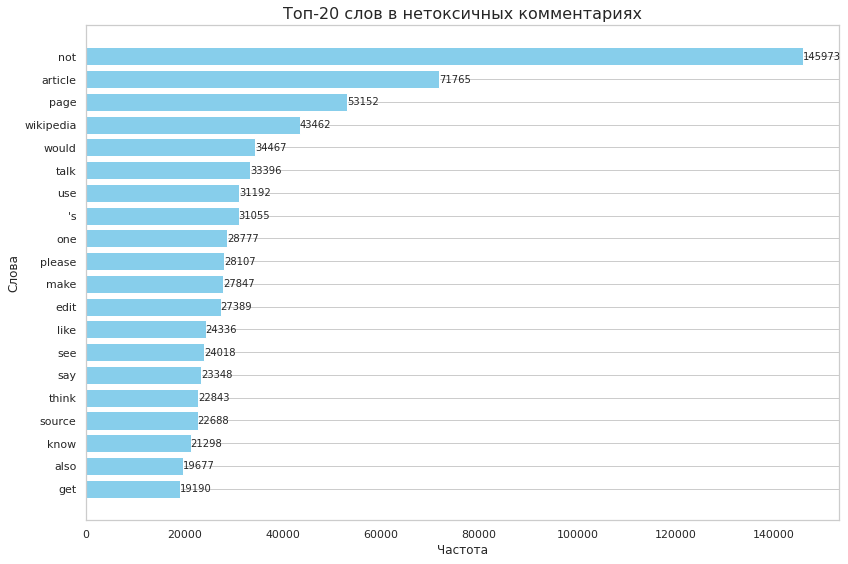

In [ ]:
# визуализация частоты слов в токсичных комментариях
# с подписями самих шкал
# данные (уже без стоп-слов)
untoxic_text = " ".join(comm[comm['toxic'] == 0]['lemm'].dropna().tolist())

# считаем частоту и берем топ-20
word_freq = Counter(untoxic_text.split())
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)  # Разделяем слова и частоты

# создаем график
plt.figure(figsize=(12, 8))
bars = plt.barh(words, counts, color='skyblue')

# добавляем подписи с количеством
for bar in bars:
    width = bar.get_width()  # получаем длину бара (частоту слова)
    plt.text(
        width + 0.5,           # x-координата (немного правее бара)
        bar.get_y() + bar.get_height()/2,  # y-координата (по центру бара)
        f'{int(width)}',        # текст (частота)
        va='center',            # вертикальное выравнивание по центру
        ha='left',              # горизонтальное выравнивание по левому краю
        fontsize=10
    )

# настройки графика
plt.title("Топ-20 слов в нетоксичных комментариях", fontsize=16)
plt.xlabel("Частота", fontsize=12)
plt.ylabel("Слова", fontsize=12)
plt.gca().invert_yaxis()  # самые частые слова сверху
plt.grid(axis='x', linestyle='--', alpha=0.4)  # сетка для удобства
plt.tight_layout()
plt.show()

Мы можем увидеть, что в обоих случаях частица 'not' занимает первое место. Также часто встречает отсылка на Википедию как в токсичных, так и нетоксичных комментариях.

Также часто встречается 'please', но целом слова в нектоксичных комментаиях более общие и нейтральные в отличие от явно негативной окраски большей части токсичных.

Также часто встречаются суффиксы собствености. Возможно, потенциально от них стоит избавиться, но пока сохраним.

Теперь, когда данные доочищены, мы можем перейти непосредственно к работе с моделями.

**Выводы**

Мы произвели анализ очищененого и лемматизированного текста и обнаружили:
- Появились явные (один и тот же текст) и неявные (один и тот же текст с разной разметкой) дубликаты, которые были удалены.
- Длина большинства комментариев не превышает сотни слов, основная часть имеет не более 39 слов.
- Средне количество слов - 36, но есть и выбросы. Максимум составил более 12 сотен слов, что уже выглядит полноценным текстом.
- Возможно, на отнесение коментариев к токсичным или нетоксичным влияет не только содержимое, но и форма: использование прописных букв и большого количества восклицательных знаков может привести к отметке "токсичный". Что потенциально можно использовать в будущем для улучшении модели (но после уточнения критериев разметки).
- Большая часть топ-20 слов в токсичных комментариях несет явную негативную окраску.
- Часть популярных слов у нетоксичных комментариев совпадает с таковыми у токсичных, однако у нетоксичных встречаются вежливые, а также в целом нетральные слова.
- Потенциально необходимо уточнить критерии, по которым комментарий относится к токсичным и перепроверить правильность разметки.

## Обучение

Для обучения будем использовать следующие модели с перебором параметров:
- DummyClassifier - как "модель сравнения";
- LogisticRegression - как "простую" модель;
- LGBMClassifier - как "сложную" модель.

### Разделение на выборки

Прежде, чем обучать модель, необходимо разбить данные на выборки.

Как мы помним, распередение классов в выборке у нас неравномерное - токсичные комментарии являются минорным классом и еле привысили отметку в 10%. Это стоит учесть при разбивке данных на выборки.

In [ ]:
# функция подготовки данных перед подбором моделей и их параметров
# со стратификацией по одному из признаков
def data_preprocessing(data, target_name):

    # Перемешивание объектов
    # для их лучшего распределения в выборках
    data = shuffle(data, random_state=RANDOM_STATE)

    # Разделение датафреймов на целевую и нецелевую выборку
    features = data.drop([target_name], axis=1)
    target = data[target_name]

    # Разделение целевой и нецелевой выборки
    # на обучающие и тестовые выборки
    X_train, X_valid, y_train, y_valid = train_test_split(
        features,
        target,
        shuffle = True, # перемешивание, больше нужно для задач классификации
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=data[target_name] # стратификация по указанному признаку, в нашем случае - целевому
    )

    return X_train, X_valid, y_train, y_valid

In [ ]:
# Разделение обучающего датафрейма на целевую и тестовую выборку
X_train, X_test, y_train, y_test = data_preprocessing(comm.drop('text', axis = 1), 'toxic')

In [ ]:
# проверка разбиения по количеству
print(color.BLUE + color.BOLD + f"Размер X_train: "\
      + color.END + f"{X_train.shape}")
print(color.BLUE + color.BOLD + f"Размер X_test: "\
      + color.END + f"{X_test.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train: "\
      + color.END + f"{y_train.shape}")
print(color.BLUE + color.BOLD + f"Размер y_test: "\
      + color.END + f"{y_test.shape}")

Размер X_train: (141681, 1)
Размер X_test: (15743, 1)
Размер y_train: (141681,)
Размер y_test: (15743,)


Выборки получены. Теперь их нужно преобразовать в пригодный для работы вид.

**Вывод**

Данные разбиты на выборки с учетом дисбаланса классов.

### Работа с моделями

Теперь, когда выборки подготовлены и преобразованы, можно приступать к работе.

Но сначала создадим словарь для записи результатов.

In [ ]:
# создаем словарь для сравнения
models_dict = {}

Кроме названия модели, ее гиперпараметров и метрики, запишем сюда также и время обучения лучшей модели (так как в нашем случае это важно).

#### DummyClassifier

Начнем с создания базовой модели, с которой будем сравнивать остальные.

In [ ]:
# функция с дамми-моделью задачи классификации
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь
# с таймером обучения лучшей модели
def Dummy_Classifier(X_train, y_train):
    # инициализация модели
    model = DummyClassifier(random_state=RANDOM_STATE)

    # Определение сетки гиперпараметров
    param_grid = {
        'strategy': ['most_frequent', # предсказывает самый частый класс
                     'prior', # предсказывает классы пропорционально их частоте
                     'stratified', # случайно, но с сохранением распределения классов
                     'uniform'] # случайно с равной вероятностью
    }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model,
        param_grid,
        scoring='f1',
        refit=False,  # НЕ переобучаем модель сразу, чтобы замерить время отдельно
        n_jobs=-1,
        cv=3,
        verbose=1
    )

    # Обучение GridSearchCV (только поиск по параметрам)
    grid_search.fit(X_train, y_train)

    # Получение лучших параметров
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    # Теперь обучаем лучшую модель отдельно и замеряем время
    start_time = time.time()
    best_model = DummyClassifier(random_state=RANDOM_STATE, **best_params)
    best_model.fit(X_train, y_train)
    best_model_time = time.time() - start_time

    print(color.BLUE + color.BOLD + f"\nЛучшая f1 при обучении: " + color.END + f"{best_score:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " + color.END + f"{best_params}\n")
    print(color.BLUE + color.BOLD + f"Время обучения лучшей модели: " + color.END + f"{best_model_time:.4f} секунд\n")

    return {
        'model': best_model,
        'best_score': best_score,
        'best_params': best_params,
        'best_model_time': best_model_time, # только время обучения лучшей модели
         #'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
#%time result_dc_tdf = Dummy_Classifier(X_train_tdf, y_train) # устар
%time result_dc_tdf = Dummy_Classifier(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшая f1 при обучении: 0.1689
Лучшие параметры: {'strategy': 'uniform'}

Время обучения лучшей модели: 0.0043 секунд

CPU times: user 409 ms, sys: 12.1 ms, total: 422 ms
Wall time: 424 ms


Лучший вариант базовой модели показал ожидаемо плохой результат.

Добавим характеристики модели в словарь для будущего сравнения.

In [ ]:
# добавляем в словарь
models_dict['Dummy_Classifier'] = {
    'params': result_dc_tdf['best_params'],
    'f1': round(result_dc_tdf['best_score'], 4),
    #'best_model_time': round(result_dc_tdf['best_model_time'], 2) # устар
    'final_train_time': round(result_dc_tdf['best_model_time'], 2)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1,final_train_time
Dummy_Classifier,{'strategy': 'uniform'},0.17,0.00


**Вывод**

Мы обучили базовую модель для возможности сравнения качества будущих моделей. Ее f1 метрика составила всего 0.17.

#### LogisticRegression

Начнем с логистической регресии как наиболее простой. Если она покажет себя хорошо, то возможно применение более сложных моделей и не потребуется.

In [ ]:
# функция с моделью логистической регрессии
# с подготовкой данных (TF-IDF) внутри функции
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь
# с таймером обучения лучшей модели
def Logistic_Regression_tdf(X_train, y_train):

     # пайплайн: TF-IDF + LogisticRegression
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('logisticregression', LogisticRegression(
            # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1 # все ядра
        ))
    ])

    # определение сетки гиперпараметров
    param_grid = [
        # во избежание ошибок совместимости с регуляризацией в обучении пришлось разделить и прописывать для каждой
        {
        'logisticregression__penalty': ['l2'],# тип регуляризации (L1 или L2)
        'logisticregression__C': [0.01, 0.1, 1] # обратная сила регуляризации
    },
    {
        'logisticregression__penalty': [None]
    }
    ]


    # создание GridSearchCV
    grid_search = GridSearchCV(
        pipeline, # подготовка и модель
        param_grid, # параметры
        scoring='f1', # метерика
        refit=False,  # НЕ переобучаем модель сразу, чтобы замерить время отдельно
        n_jobs=-1, # все ядра
        cv=3, # количество фолдов
        verbose=1 # не выключаем вывод, чтобы видеть прогресс от sklearn, так как tqdm не поодерживает n_jobs=-1
    )

    # поиск лучших параметров (кросс-валидация), можно с замером времени
    # start_cv_time = time.time() # старт замера
    # grid_search.fit(X_train.values.astype('U'), y_train) # подойдет для русского языка
    # здесь мы не приводим в Unicod, так как у нас английский язык и мы уже избавились от лишнего ранее
    # (изменение кодировки увеличивает количество оперативной памяти, необходимой для хранения текстов
    # и может привести к падению ядра)
    grid_search.fit(X_train, y_train) # X_train - сырой текст
    # cv_time = time.time() - start_cv_time # конец замера

    # финализация модели на всех данных с лучшими параметрами
    # узнаем лучшие параметры
    best_params = grid_search.best_params_

    # создаем лучшую модель заново
    # используем этот метод для упрощения, так как не перебирали параметры TfidfVectorizer()
    best_model = LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **{k.replace('logisticregression__', ''): v
           for k, v in best_params.items()}
    )

    # создаем новый пайплайн с лучшей моделью
    final_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', best_model)
    ])

    # Обучение на всех данных + замер времени
    start_time = time.time() # старт замера
    final_pipeline.fit(X_train, y_train)
    final_time = time.time() - start_time # конец замера

    # Результаты
    print(color.BLUE + color.BOLD + f"\nЛучшая F1 на CV: " + color.END + f"{grid_search.best_score_:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " + color.END + f"{best_params}")
    # print(color.BLUE + color.BOLD + f"Время кросс-валидации: " + color.END + f"{cv_time:.2f} сек")
    print(color.BLUE + color.BOLD + f"Время финального обучения: " + color.END + f"{final_time:.2f} сек")

    return {
        'model': final_pipeline,
        'best_score': grid_search.best_score_,
        'best_params': best_params,
        #'cv_time': cv_time,
        'final_train_time': final_time
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
#%time result_lc_tdf = Logistic_Regression(X_train_tdf, y_train) # устар
# преобразуем уже внутри функции
%time result_lc_tdf = Logistic_Regression_tdf(X_train['lemm'], y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшая F1 на CV: 0.7545
Лучшие параметры: {'logisticregression__penalty': None}
Время финального обучения: 32.25 сек
CPU times: user 2min 21s, sys: 1min 4s, total: 3min 26s
Wall time: 3min 27s


In [ ]:
# добавляем в словарь
models_dict['Logistic_Regression (tdf)'] = {
    'params': result_lc_tdf['best_params'],
    'f1': round(result_lc_tdf['best_score'], 4),
#    'best_model_time': round(result_lc_tdf['best_model_time'], 2) # устар
    'final_train_time': round(result_lc_tdf['final_train_time'], 2)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1,final_train_time
Dummy_Classifier,{'strategy': 'uniform'},0.17,0.00
Logistic_Regression (tdf),{'logisticregression__penalty': None},0.75,32.25


**Вывод**

Мы обучили модель Логистической классификации. Ее f1-метрика при обучении составила 0.7558.

#### LGBMClassifier

Предыдущая модель при обучении показала неплохой результат, если удасться повторить который на тесте уже будет соответсвовать требованиям заказчика. Но может быть более сложная модель сможет выбрать лучший результат?

Проверим это.

In [ ]:
# функция с моделью LGBMClassifier
# с подготовкой данных (TF-IDF) внутри функции
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь
# с таймером обучения лучшей модели
def LGBM_Classifier_tdf(X_train, y_train):

    # пайплайн: TF-IDF + LGBM
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('lgbm', LGBMClassifier(
            # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1, # все ядра
            verbose=0  # отключаем вывод информации
        ))
    ])


    """
    n_estimators: Количество деревьев в лесу.
    Большее значение может улучшить точность, но увеличит время обучения.
    """
    # определение сетки гиперпараметров
    # глубина не очень сбалансирована по отношению к количеству листьев (31 по умолчанию)
    param_grid = {
    'lgbm__n_estimators': [25, 50], # количество деревьев в лесу
    'lgbm__max_depth': [10, 15], # максимальная глубина дерева
    'lgbm__learning_rate': [0.4] # скорость обучения
    }

   # Создание GridSearchCV
    grid_search = GridSearchCV(
        pipeline, # подготовка и модель
        param_grid, # параметры
        scoring='f1', # метерика
        refit=False,  # НЕ переобучаем модель сразу, чтобы замерить время отдельно
        n_jobs=-1, # все ядра
        cv=3, # количество фолдов
        verbose=1 # не выключаем вывод, чтобы видеть прогресс от sklearn, так как tqdm не поодерживает n_jobs=-1
    )

    # поиск лучших параметров (кросс-валидация), можно с замером времени
    # start_cv_time = time.time() # старт замера
    # grid_search.fit(X_train.values.astype('U'), y_train) # подойдет для русского языка
    # здесь мы не приводим в Unicod, так как у нас английский язык и мы уже избавились от лишнего ранее
    # (изменение кодировки увеличивает количество оперативной памяти, необходимой для хранения текстов
    # и может привести к падению ядра)
    grid_search.fit(X_train, y_train)
    # cv_time = time.time() - start_cv_time # конец замера

    # финализация модели на всех данных с лучшими параметрами
    # узнаем лучшие параметры
    best_params = grid_search.best_params_

    # создаем лучшую модель заново
    # используем этот метод для упрощения, так как не перебирали параметры TfidfVectorizer()
    best_model = LGBMClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        **{k.replace('lgbm__', ''): v
           for k, v in best_params.items()}
    )

    # создаем новый пайплайн с лучшей моделью
    final_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('model', best_model)
    ])

    # Обучение на всех данных + замер времени
    start_time = time.time() # старт замера
    final_pipeline.fit(X_train, y_train)
    final_time = time.time() - start_time # конец замера

    # Результаты
    print(color.BLUE + color.BOLD + f"\nЛучшая F1 на CV: " + color.END + f"{grid_search.best_score_:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " + color.END + f"{best_params}")
    # print(color.BLUE + color.BOLD + f"Время кросс-валидации: " + color.END + f"{cv_time:.2f} сек")
    print(color.BLUE + color.BOLD + f"Время финального обучения: " + color.END + f"{final_time:.2f} сек")

    return {
        'model': final_pipeline,
        'best_score': grid_search.best_score_,
        'best_params': best_params,
        #'cv_time': cv_time,
        'final_train_time': final_time
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
#%time result_lbbm_tdf = LGBM_Classifier(X_train_tdf, y_train) # устар
%time result_lbbm_tdf = LGBM_Classifier_tdf(X_train['lemm'], y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 17.081222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 16.699205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2

На кросс-валидации данной модели мы получили метрику хуже, чем у предыдущей, при этом затратив гораздо больше времени на обучение (не говоря уже про подбор гиперпараметров).

Возможно, указав больше вариантов гиперпарамеров и дав модели больше времени нам получится превзойти результат логистической регресии. Однако (кроме возрастания времени обучения и потребляемых мощностей) у нас возникает риск переобучения больший, чем для логистической регресии, так как деревьям проще подстроиться под выборку.

In [ ]:
# добавляем в словарь
models_dict['LGBM_Classifier (tdf)'] = {
    'params': result_lbbm_tdf['best_params'],
    'f1': round(result_lbbm_tdf['best_score'], 4),
    #'best_model_time': round(result_lbbm_tdf['best_model_time'], 2) # устар
    'final_train_time': round(result_lbbm_tdf['final_train_time'], 2)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1,final_train_time
Dummy_Classifier,{'strategy': 'uniform'},0.17,0.00
Logistic_Regression (tdf),{'logisticregression__penalty': None},0.75,32.25
LGBM_Classifier (tdf),"{'lgbm__learning_rate': 0.4, 'lgbm__max_depth': 15, 'lgbm__n_estimators': 50}",0.74,133.94


**Вывод**

Мы обучили модель LGBMClassifier, чья метрика f1 составила 0.74.

### Векторизация (мешок слов)

Предыдущие модели обучались с помощью величины TF-IDF, оценивающей важность слова. Попробуем применить иные подходы.

Преобразуем данные с помощью мешка слов. Делать это будем также внутри функции.

Преобразовывать тестовую пока не будем, пока не найдем лучшую из моделей.

#### LogisticRegression

Результты для Дамми-модели (так как ей не важны признаки) будут те же, поэтому нет смысла переобучать ее. А c учетом предыдущего опыта, на мешке будем испытавать только Логистическую регресию.

Для чистоты эксперимента обучим модель с теми же гиперпараметрами на получившемся мешке слов.

In [ ]:
# функция с моделью LGBMClassifier
# с подготовкой данных (мешок слов) внутри функции
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь
# с таймером обучения лучшей модели

def Logistic_Regression_bow(X_train, y_train):
       # Пайплайн: CountVectorizer + LogisticRegression
    pipeline = Pipeline([
        # заменили TF-IDF на BOW
        # добавлен параметр `dtype='float64'` для `CountVectorizer`,
        # чтобы избежать предупреждений при работе с LogisticRegression.
        ('countvectorizer', CountVectorizer(dtype='float64')),
        ('logisticregression', LogisticRegression(
            # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1 # все ядра
        ))
    ])

    # cетка гиперпараметров
   # определение сетки гиперпараметров
    param_grid = [
        # во избежание ошибок совместимости с регуляризацией в обучении пришлось разделить и прописывать для каждой
        {
        'logisticregression__penalty': ['l2'],# тип регуляризации (L1 или L2)
        'logisticregression__C': [0.01, 0.1, 1] # обратная сила регуляризации
    },
    {
        'logisticregression__penalty': [None]
    }
    ]

    # создание GridSearchCV
    grid_search = GridSearchCV(
        pipeline, # подготовка и модель
        param_grid, # параметры
        scoring='f1', # метерика
        refit=False,  # НЕ переобучаем модель сразу, чтобы замерить время отдельно
        n_jobs=-1, # все ядра
        cv=3, # количество фолдов
        verbose=1 # не выключаем вывод, чтобы видеть прогресс от sklearn, так как tqdm не поодерживает n_jobs=-1
    )

    # поиск лучших параметров (кросс-валидация), можно с замером времени
    # start_cv_time = time.time() # старт замера
    # grid_search.fit(X_train.values.astype('U'), y_train) # подойдет для русского языка
    # здесь мы не приводим в Unicod, так как у нас английский язык и мы уже избавились от лишнего ранее
    # (изменение кодировки увеличивает количество оперативной памяти, необходимой для хранения текстов
    # и может привести к падению ядра)
    grid_search.fit(X_train, y_train) # X_train - сырой текст
    # cv_time = time.time() - start_cv_time # конец замера

     # финализация модели на всех данных с лучшими параметрами
    # узнаем лучшие параметры
    best_params = grid_search.best_params_

    # создаем лучшую модель заново
    # используем этот метод для упрощения, так как не перебирали параметры TfidfVectorizer()
    best_model = LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **{k.replace('logisticregression__', ''): v
           for k, v in best_params.items()}
    )

    # создаем новый пайплайн с лучшей моделью
    final_pipeline = Pipeline([
        ('countvectorizer', CountVectorizer(dtype='float64')),
        ('model', best_model)
    ])

    # Обучение на всех данных + замер времени
    start_time = time.time() # старт замера
    final_pipeline.fit(X_train, y_train)
    final_time = time.time() - start_time # конец замера

    # Результаты
    print(color.BLUE + color.BOLD + f"\nЛучшая F1 на CV: " + color.END + f"{grid_search.best_score_:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " + color.END + f"{best_params}")
    # print(color.BLUE + color.BOLD + f"Время кросс-валидации: " + color.END + f"{cv_time:.2f} сек")
    print(color.BLUE + color.BOLD + f"Время финального обучения: " + color.END + f"{final_time:.2f} сек")

    return {
        'model': final_pipeline,
        'best_score': grid_search.best_score_,
        'best_params': best_params,
        #'cv_time': cv_time,
        'final_train_time': final_time
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
# преобразуем уже внутри функции
%time result_lc_bow = Logistic_Regression_bow(X_train['lemm'], y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _che


Лучшая F1 на CV: 0.7579
Лучшие параметры: {'logisticregression__C': 1, 'logisticregression__penalty': 'l2'}
Время финального обучения: 50.49 сек
CPU times: user 5min 25s, sys: 3min 42s, total: 9min 8s
Wall time: 9min 10s


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# добавляем в словарь
models_dict['Logistic_Regression (bow)'] = {
    'params': result_lc_bow['best_params'],
    'f1': round(result_lc_bow['best_score'], 4),
    #'best_model_time': round(result_lc_bow['best_model_time'], 2) # устар
    'final_train_time': round(result_lc_bow['final_train_time'], 2)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,f1,final_train_time
Dummy_Classifier,{'strategy': 'uniform'},0.17,0.00
Logistic_Regression (tdf),{'logisticregression__penalty': None},0.75,32.25
LGBM_Classifier (tdf),"{'lgbm__learning_rate': 0.4, 'lgbm__max_depth': 15, 'lgbm__n_estimators': 50}",0.74,133.94
Logistic_Regression (bow),"{'logisticregression__C': 1, 'logisticregression__penalty': 'l2'}",0.76,50.49


Данная модель показала также неплохой результат, однако потребовала больше времени на обучение и оказалась не слишком приспособленной к работе с выбросами.

**Вывод**

Мы обучили модель Логистической регресии, используя мешок слов. Ее f1-метрика составила 0.7588.

### Сравнение моделей

Выведем сравнительный словарь характеристик моделей, отсортировав его по убыванию метрики.

In [ ]:
# Вывод моделей и их метрик с сортировкой по убыванию метрики с сортировкой
pd.DataFrame.from_dict(models_dict, orient='index').sort_values(by='f1', ascending=False)

,params,f1,final_train_time
Logistic_Regression (bow),"{'logisticregression__C': 1, 'logisticregression__penalty': 'l2'}",0.76,50.49
Logistic_Regression (tdf),{'logisticregression__penalty': None},0.75,32.25
LGBM_Classifier (tdf),"{'lgbm__learning_rate': 0.4, 'lgbm__max_depth': 15, 'lgbm__n_estimators': 50}",0.74,133.94
Dummy_Classifier,{'strategy': 'uniform'},0.17,0.00


Оба варианта логистической регрессии показали себя хорошо. Однако модели, обучавшаяся на мешке слов, потребовалось больше времени при не слишком большом росте метрики.

Посмотрим разницу в метрике более наглядно.

In [ ]:
# сравниваем метрики
print(color.BLUE + color.BOLD + f" Лучшая f1 при обучении Logistic_Regression (tdf): " + color.END
      + f"{round(result_lc_tdf['best_score'], 4)}")
print(color.BLUE + color.BOLD + f" Лучшая f1 при обучении Logistic_Regression (bow): " + color.END
      + f"{round(result_lc_bow['best_score'], 4)}")
print(color.BLUE + color.BOLD + f" Разница метрик f1 между ними: " + color.END
      + f"{round(result_lc_bow['best_score'] - result_lc_tdf['best_score'], 4)}")

 Лучшая f1 при обучении Logistic_Regression (tdf): 0.7545
 Лучшая f1 при обучении Logistic_Regression (bow): 0.7579
 Разница метрик f1 между ними: 0.0034


Разница прироста метрики у Logistic_Regression (bow) незначительна, а вот время обучения отличается уже более заметно даже сейчас, что станет еще более заметным на большем количестве данных. Тем более, что ей больше мешают выбросы, чем Logistic_Regression (tdf), а значит потенциально данные требуют большей подготовки.

Поэтому, несмотря на немного меньшую метрику на тренировочных данных, лучшей моделью стала Logistic_Regression, обученная на TF-IDF.

**Вывод**

Лучшей моделью признана Logistic_Regression, обученная на TF-IDF.

### Получение предсказания на тесте

Получим предсказание на тестовых данных и узнаем его метрику.

In [ ]:
# вычисляем метрику F1 на тесте
# вариант сохранением предсказания, чтобы можно применять еще где-нибудь
prediction = result_lc_tdf['model'].predict(X_test['lemm']) # получаем предсказание
# вычисляем метрику с сохранением
f1_score_test = f1_score(y_test, prediction)
print(color.BLUE + color.BOLD + f" Метрика f1 лучшей модели на тестовых данных: " + color.END
      + f"{round(f1_score_test, 4)}")
try:
    f1_score_test >= 0.75
    print(color.BLUE + color.BOLD + f" Отлично! Модель соответствует требованию заказчика" + color.END)
except:
    print(color.BLUE + color.BOLD + f" Плохо! Модель НЕ соответствует требованию заказчика" + color.END)

 Метрика f1 лучшей модели на тестовых данных: 0.7531
 Отлично! Модель соответствует требованию заказчика


Согласно требованию заказчика метрика f1 должна быть не меньше 0.75, а значит наша модель удовлетворяет требованию заказчика.

**Вывод**

Лучшая модель удовлетворяет требованию заказчика.

### Матрица ошибок и кривые

Дополнительно мы можем визуализировать, насколько верно и уверенно наша лучшая модель дает ответы.

Так как у нас несбалансированная выборка, то кривая Precision-Recall более полезна, чем ROC-AUC (в отличие от Precision-Recall, ROC-AUC может быть менее информативной, так как чувствительна к балансу классов). Посмотрим на обе кривые, но преимущество в оценки модели будет у первой.

In [ ]:
# создание функции
def display_model_performance(y_true, y_pred, y_scores, model_name):
    """
    Визуализирует матрицу ошибок, кривую Precision-Recall и ROC-AUC
    с русскоязычными подписями
    """
    # Создаем фигуру с тремя subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # 1. Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    cmd = ConfusionMatrixDisplay(cm, display_labels=['0', '1'])
    cmd.plot(cmap='Blues', ax=ax1, values_format='d')
    # подписи
    ax1.set_title(f'Матрица ошибок для {model_name}', pad=20)
    ax1.set_xlabel('Предсказанный класс', labelpad=10)
    ax1.set_ylabel('Истинный класс', labelpad=10)
    ax1.xaxis.set_ticklabels(['Отрицательный', 'Положительный'])
    ax1.yaxis.set_ticklabels(['Отрицательный', 'Положительный'])

    # 2. Кривая Precision-Recall
    prec, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_display = PrecisionRecallDisplay(precision=prec, recall=recall)
    pr_display.plot(ax=ax2)
    ax2.set_title(f'Кривая Precision-Recall для {model_name}', pad=20)
    ax2.set_xlabel('Полнота (Recall)', labelpad=10)
    ax2.set_ylabel('Точность (Precision)', labelpad=10)
    ax2.legend(['Кривая PR'], loc='upper right')

    # 3. Кривая ROC-AUC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    roc_display.plot(ax=ax3)
    ax3.set_title(f'ROC-кривая для {model_name}', pad=20)
    ax3.set_xlabel('Доля ложноположительных (FPR)', labelpad=10)
    ax3.set_ylabel('Доля истинноположительных (TPR)', labelpad=10)
    ax3.legend([f'AUC = {roc_auc:.3f}'], loc='lower right')

    plt.tight_layout()
    plt.show()

    # Текстовый отчёт на русском
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    print(color.BLUE + color.BOLD + f"\nТекстовый отчёт:"+ color.END)
    print(f"Истинно отрицательные (TN): {tn} ({tn/total:.1%})")
    print(f"Ложноположительные (FP): {fp} ({fp/total:.1%})")
    print(f"Ложноотрицательные (FN): {fn} ({fn/total:.1%})")
    print(f"Истинноположительные (TP): {tp} ({tp/total:.1%})")
    print(f"\nТочность (Precision) = TP/(TP+FP): {tp/(tp+fp):.3f}")
    print(f"Полнота (Recall) = TP/(TP+FN): {tp/(tp+fn):.3f}")
    print(f"F1-score: {2*tp/(2*tp+fp+fn):.3f}")
    print(f"AUC-ROC: {roc_auc:.3f}")

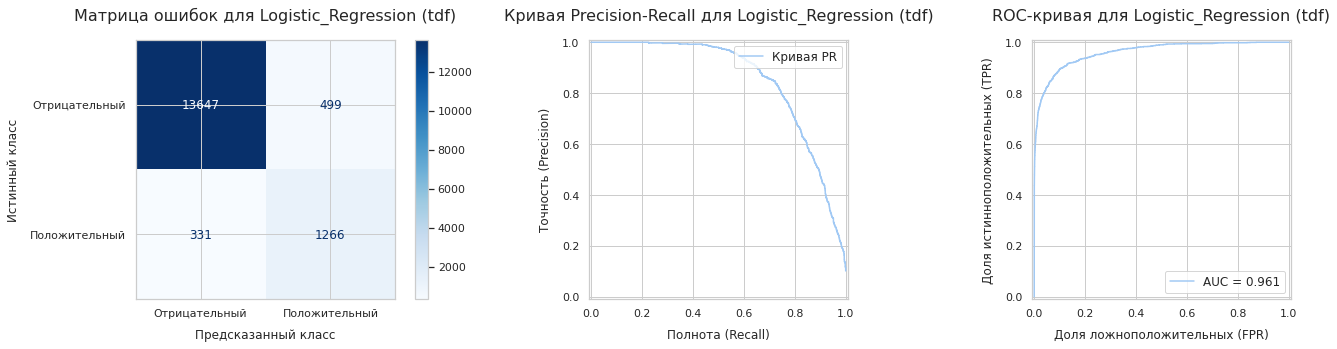


Текстовый отчёт:
Истинно отрицательные (TN): 13647 (86.7%)
Ложноположительные (FP): 499 (3.2%)
Ложноотрицательные (FN): 331 (2.1%)
Истинноположительные (TP): 1266 (8.0%)

Точность (Precision) = TP/(TP+FP): 0.717
Полнота (Recall) = TP/(TP+FN): 0.793
F1-score: 0.753
AUC-ROC: 0.961


In [ ]:
# применяем функцию
display_model_performance(
    y_test,
    prediction,  # предсказанные классы
    result_lc_tdf['model'].predict_proba(X_test['lemm'])[:, 1],  # вероятности положительного класса
    'Logistic_Regression (tdf)'
)

При анализе матрицы ошибок можно наблюдать, что модель хорошо предсказывает отрицательный класс (что логично, так как большинство данных в выборке относилось именно к нему).

Изучая кривую Precision-Recall можно заметить:
- Форма кривой типична для большинства моделей классификации (начинается с высокой точности (Precision) при низкой полноте (Recall), а по мере увеличения полноты точность постепенно снижается).
- Судя по площади под кривой можно сказать, что в целом модель хорошо разделяет классы, но для увеличения выявления положительных случаев можно откорректировать порог (при этом точность снизится).
- В начале кривой (низкий Recall) модель демонстрирует высокую Precision - значит, когда модель уверена в положительном классе, она обычно права. А по мере увеличения Recall Precision снижается умеренно, что является хорошим признаком.

Изучая кривую AUC-ROC можно заметить:
- Большую площадь под кривой, что также подтвержает хорошую способность модели разделять на классы.
- Модель правильно идентифицирует большинство истинноположительных случаев.

**Выводы**

Анализ предсказания модели показал:
- В целом модель хорошо разделяет классы.
- Модель хорошо предсказывает отрицательный класс.
- Модель правильно идентифицирует большинство истинноположительных случаев. При этом, когда модель уверенна в положительном классе, она обычно права.
- Чтобы не упускать положительные случаи, мы можем изменить порог (увеличив полноту ценой снижения точности).

## Выводы

В ходе изучения данных мы обнаружили:
- На анализ получены данные, состоящие из более 150 тыс строк.
- Имелся лишний столбец, предположительно содержавший старые индексы, который был удален.
- Данные недосточно очищены и содержат "артефакты" (например, имеются IP адреса и служебные отметки).
- В данных имеются скрытые дубликаты, часть из которых получила разные метки. Дубликаты были удалены.
- Пропуски в данных не обнаружены.
- Средняя длина текста - 36 лемм, большинсто не превышает 39.
- Есть аномально длинные тексты и выбросы (максимальная длинна - более 12 сотен лемм).
- Имеется дисбаланс классов (важный для нас класс 1 едва превышает 10%), то есть в целом комьюнити магазина вполне дружелюбное.
- Возможно, на отнесение коментариев к токсичным или нетоксичным влияет не только содержимое, но и форма: использование прописных букв и большого количества восклицательных знаков может привести к отметке "токсичный". Что потенциально можно использовать в будущем для улучшении модели (но после уточнения критериев разметки).
- Большая часть топ-20 слов в токсичных комментариях несет явную негативную окраску.
- Часть популярных слов у нетоксичных комментариев совпадает с таковыми у токсичных, однако у нетоксичных встречаются вежливые, а также в целом нетральные слова.
- Потенциально необходимо уточнить критерии, по которым комментарий относится к токсичным и перепроверить правильность разметки.

При подготовки данных мы:
- Удалили часть "артефактов" и стоп-слов, токенизировали и лемматизировали текст.
- Векторизировали его несколькими вариантами (TF-IDF и мешок слов) для сравнения качества обучения моделей.

В ходе обучения моделей мы обучили с учетом подбора гиперпараметров:
- Базовую модель;
- Логистическую регресию на нескольких вариантах подготовки данных (TF-IDF и мешок слов);
- LGBMClassifier, обученную на данных, подготовленных с помощью TF-IDF.

После сравнения метрик при обучении и времени обучения лучшей моделью признана логистическая регрессия, обученная на данных, подготовленных с помошью TF-IDF. Ее параметры, метрика при обучении и время обучения представлены ниже.

In [ ]:
# описание модели
pd.DataFrame.from_dict(models_dict, orient='index').loc[['Logistic_Regression (tdf)']]

,params,f1,final_train_time
Logistic_Regression (tdf),{'logisticregression__penalty': None},0.75,32.25


Метрика данной модели на тесте составила:

In [ ]:
# метрика лучшей модели на тесте
print(color.BLUE + color.BOLD + f" Метрика f1 лучшей модели на тестовых данных: " + color.END
      + f"{round(f1_score_test, 4)}")

 Метрика f1 лучшей модели на тестовых данных: 0.7531


Данная метрика выше требуемого заказчика порога (значение метрики F1 не меньше 0.75), а значит она удовлетворяет требованию заказчика.

Анализ предсказания модели показал:
- В целом модель хорошо разделяет классы.
- Модель хорошо предсказывает отрицательный класс.
- Модель правильно идентифицирует большинство истинноположительных случаев. При этом, когда модель уверенна в положительном классе, она обычно права.
- Чтобы не упускать положительные случаи, мы можем изменить порог (увеличив полноту ценой снижения точности).